In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

In [2]:
SAMPLE_DIR = Path("../data/sample")

# Get all patch base names
all_files = sorted(SAMPLE_DIR.iterdir())
patch_bases = sorted(set(f.name.split(".")[0] for f in all_files))

print(f"Total patches found: {len(patch_bases)}")
print(f"\nFirst 3 patch base names:")
for b in patch_bases[:3]:
    print(f"  {b}")

Total patches found: 100

First 3 patch base names:
  b01_009894_1665_xi_13s042w_b02_010606_1666_xn_13s042w_00003
  b01_009894_1665_xi_13s042w_b02_010606_1666_xn_13s042w_00018
  b01_009894_1665_xi_13s042w_b02_010606_1666_xn_13s042w_00035


In [3]:
def load_patch(sample_dir: Path, base: str) -> dict:
    return {
        "optical":    np.array(Image.open(sample_dir / f"{base}.optical.png")),
        "elevation":  np.array(Image.open(sample_dir / f"{base}.elevation.tif")),
        "nan_mask":   np.array(Image.open(sample_dir / f"{base}.initial_nan_mask.png")),
        "dev_mask":   np.array(Image.open(sample_dir / f"{base}.deviation_mask.png")),
    }

# Test on first patch
patch = load_patch(SAMPLE_DIR, patch_bases[0])
for k, v in patch.items():
    print(f"{k:12s}: shape={v.shape}, dtype={v.dtype}, min={v.min()}, max={v.max()}")

optical     : shape=(518, 518, 3), dtype=uint8, min=0, max=168
elevation   : shape=(518, 518), dtype=float32, min=1169.3585205078125, max=1442.1806640625
nan_mask    : shape=(518, 518), dtype=uint8, min=0, max=255
dev_mask    : shape=(518, 518), dtype=uint8, min=0, max=255


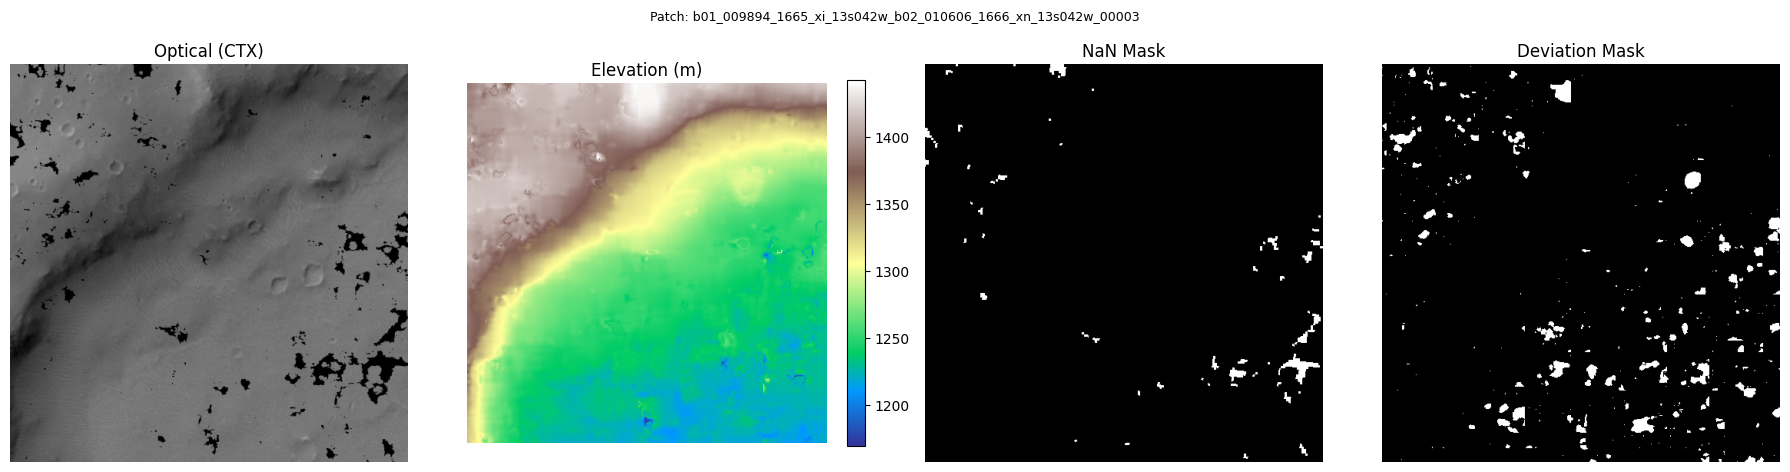

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f"Patch: {patch_bases[0]}", fontsize=9)

axes[0].imshow(patch["optical"], cmap="gray")
axes[0].set_title("Optical (CTX)")

axes[1].imshow(patch["elevation"], cmap="terrain")
axes[1].set_title("Elevation (m)")
plt.colorbar(axes[1].images[0], ax=axes[1], fraction=0.046)

axes[2].imshow(patch["nan_mask"], cmap="gray")
axes[2].set_title("NaN Mask")

axes[3].imshow(patch["dev_mask"], cmap="gray")
axes[3].set_title("Deviation Mask")

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Understanding the Four MCTED Data Channels

Each patch in the MCTED dataset consists of four files sharing the same base name.

### 1. Optical (CTX) — `.optical.png`
The raw grayscale image captured by the Context Camera (CTX) aboard Mars Reconnaissance Orbiter (MRO) at ~6 m/pixel. Saved as RGB but all three channels are identical — it is effectively a single-channel grayscale image. This is the **only input** the model sees at inference time. Visual features like shading gradients, crater rim shadows, and texture patterns are the cues the model uses to infer terrain geometry.

### 2. Elevation — `.elevation.tif`
The ground-truth Digital Elevation Model (DEM) in float32, with pixel values representing **absolute elevation in meters** above the Martian areoid (the Mars equivalent of sea level). This is derived from CTX stereo photogrammetry — two overlapping CTX images taken from slightly different angles are matched to reconstruct 3D geometry. This is the **prediction target** for all deep learning implementations. During training, we subtract the per-patch mean to convert absolute elevation to relative topography, so the model learns terrain shape rather than absolute altitude.

### 3. NaN Mask — `.initial_nan_mask.png`
A binary mask (0 = valid, 255 = invalid) marking pixels where the stereo matching pipeline **failed to produce any elevation estimate**. These are regions where the two CTX stereo images could not be reliably matched — typically deep shadows, textureless flat surfaces, or occluded areas. These pixels were filled in the DEM using interpolation by the MCTED pipeline, so their elevation values are not real measurements. They must be excluded from both training loss and evaluation metrics.

### 4. Deviation Mask — `.deviation_mask.png`
A binary mask (0 = valid, 255 = invalid) marking pixels flagged as **elevation outliers** during MCTED's artifact removal step. These are pixels where the stereo-derived elevation deviates excessively from a smoothed reference surface — typically caused by matching errors at crater walls, boulder edges, or steep scarps where stereo geometry breaks down. Like the NaN mask, these pixels must be excluded from loss and evaluation.

### Combined Validity Mask
The usable pixels for training and evaluation are those flagged as valid in **both** masks:
```python
valid_mask = (nan_mask == 0) & (dev_mask == 0)
```
In practice, ~95% of pixels per patch are valid, with invalid regions clustered around shadows and steep terrain boundaries.

Total pixels  : 268324
Valid pixels  : 256093 (95.4%)
Invalid pixels: 12231 (4.6%)


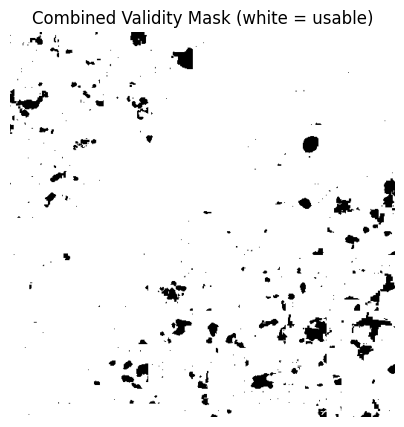

In [5]:
valid_mask = (patch["nan_mask"] == 0) & (patch["dev_mask"] == 0)

total_pixels = valid_mask.size
valid_pixels = valid_mask.sum()

print(f"Total pixels  : {total_pixels}")
print(f"Valid pixels  : {valid_pixels} ({100 * valid_pixels / total_pixels:.1f}%)")
print(f"Invalid pixels: {total_pixels - valid_pixels} ({100 * (1 - valid_pixels/total_pixels):.1f}%)")

plt.figure(figsize=(5, 5))
plt.imshow(valid_mask, cmap="gray")
plt.title("Combined Validity Mask (white = usable)")
plt.axis("off")
plt.show()

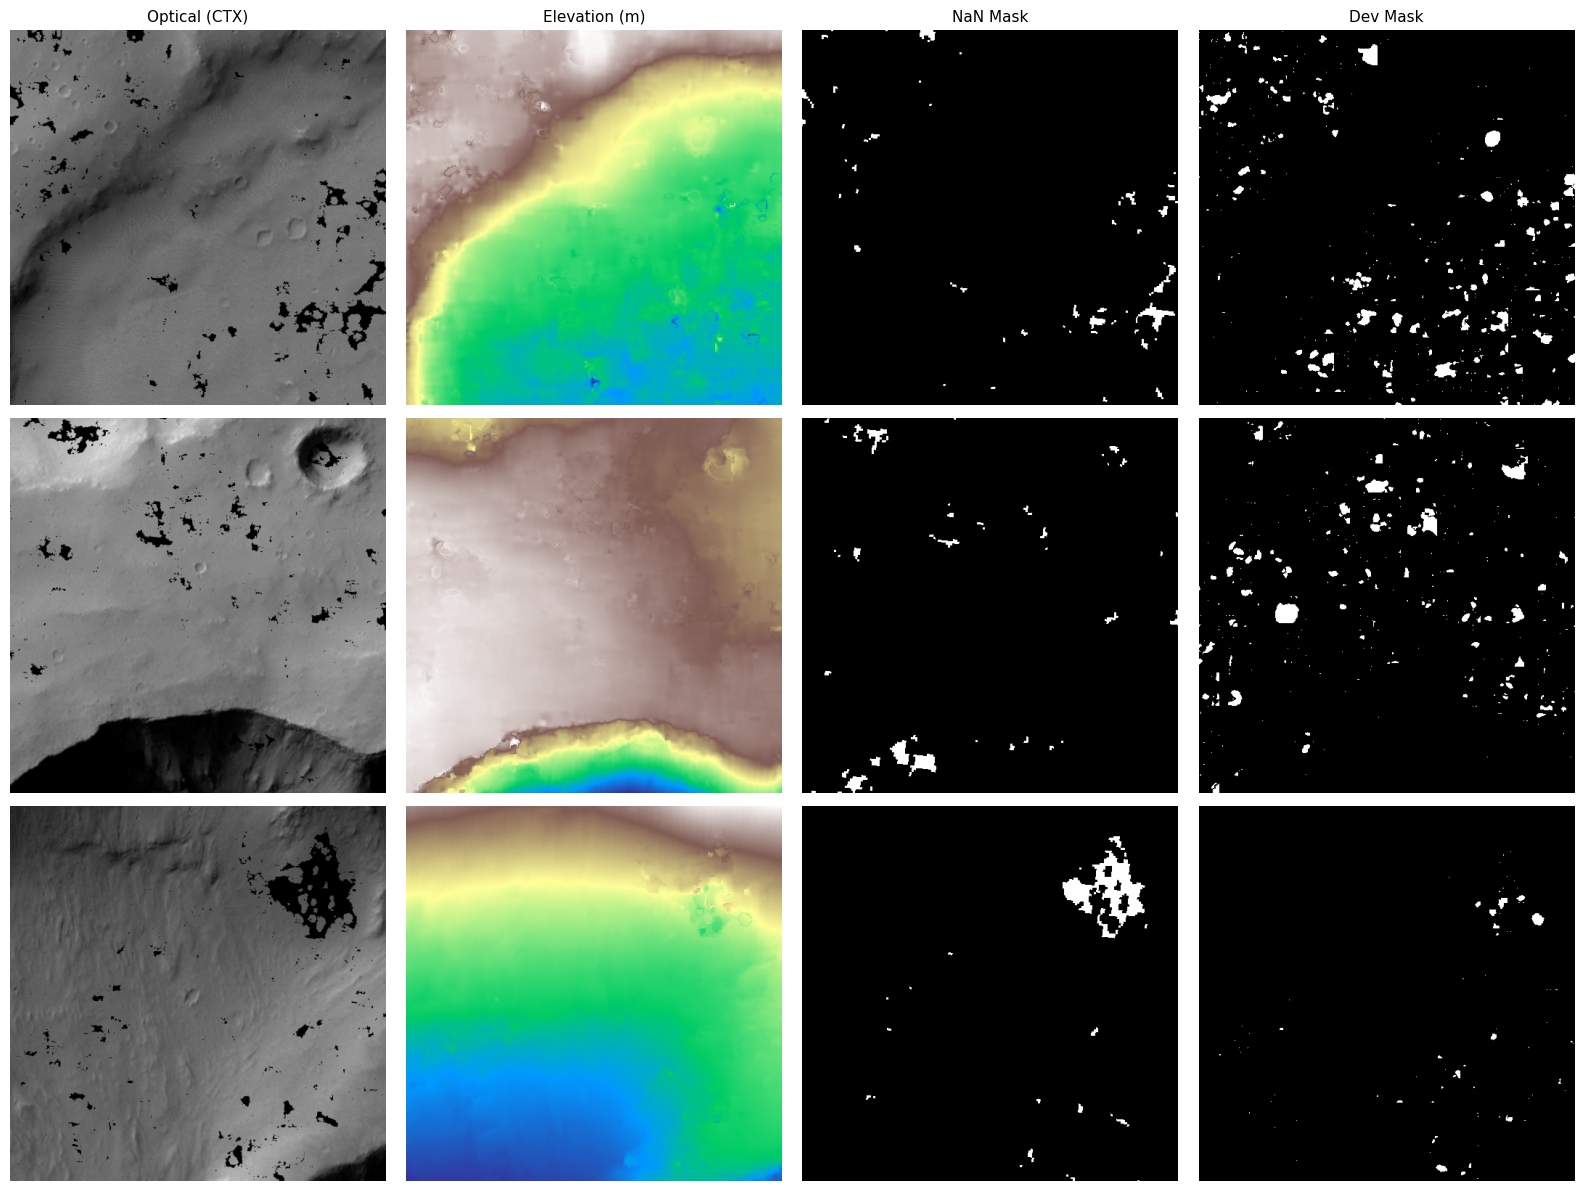

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
col_titles = ["Optical (CTX)", "Elevation (m)", "NaN Mask", "Dev Mask"]

for col, title in enumerate(col_titles):
    axes[0][col].set_title(title, fontsize=11)

for row, base in enumerate(patch_bases[:3]):
    p = load_patch(SAMPLE_DIR, base)
    valid = (p["nan_mask"] == 0) & (p["dev_mask"] == 0)
    valid_pct = 100 * valid.sum() / valid.size

    axes[row][0].imshow(p["optical"], cmap="gray")
    axes[row][0].set_ylabel(f"#{row}\n{valid_pct:.1f}% valid", fontsize=7)

    axes[row][1].imshow(p["elevation"], cmap="terrain")
    axes[row][2].imshow(p["nan_mask"], cmap="gray")
    axes[row][3].imshow(p["dev_mask"], cmap="gray")

    for ax in axes[row]:
        ax.axis("off")

plt.tight_layout()
plt.show()

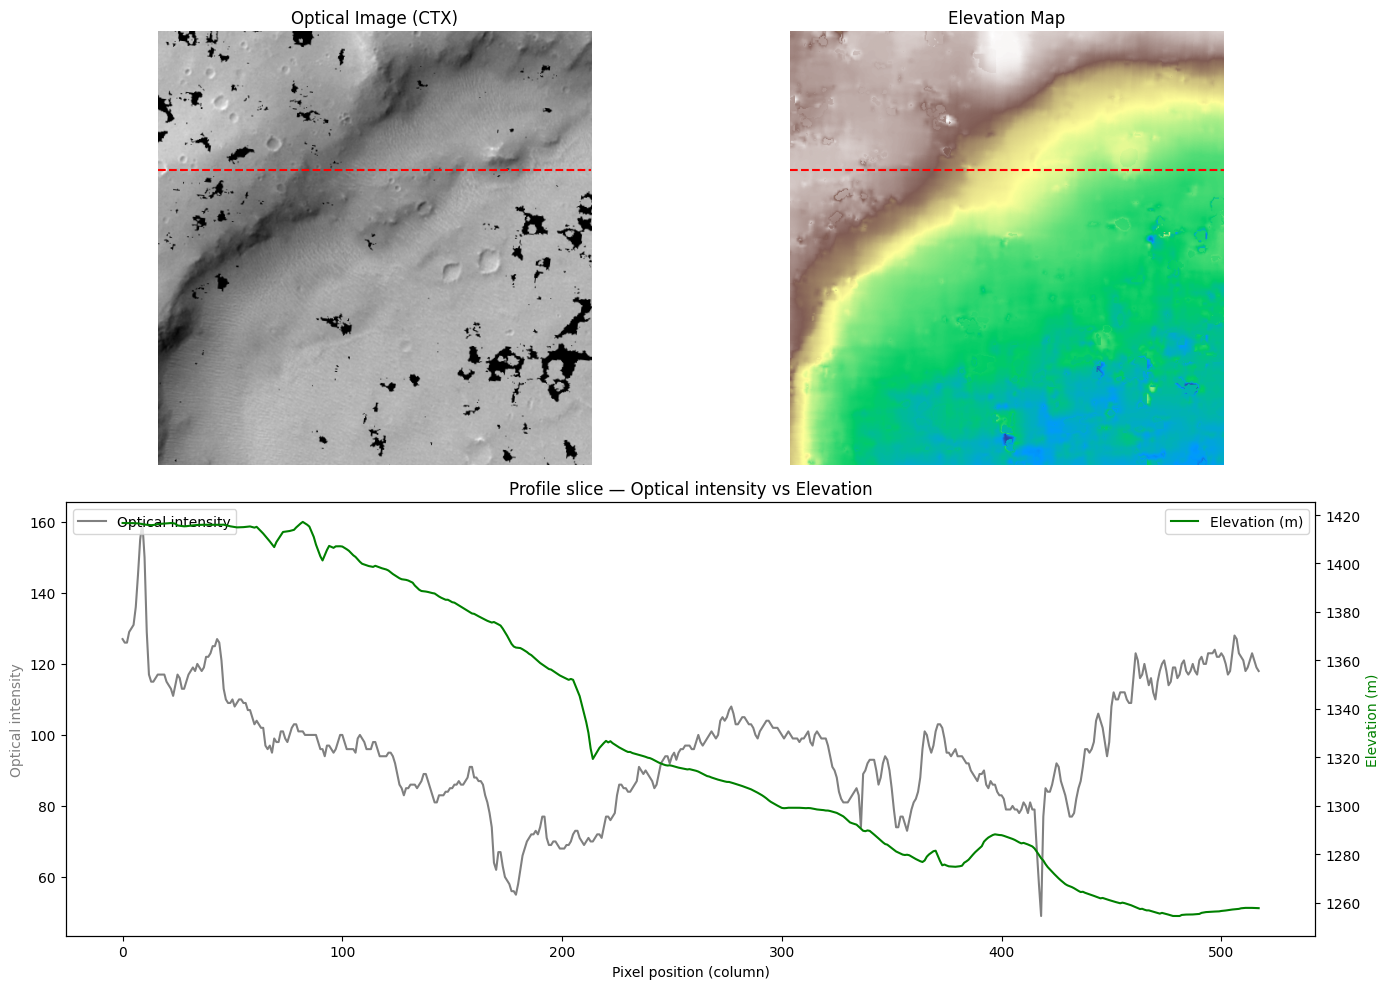

In [7]:
fig = plt.figure(figsize=(14, 10))

ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 1, 2)

optical_gray = patch["optical"][:, :, 0]
elev         = patch["elevation"]
valid        = (patch["nan_mask"] == 0) & (patch["dev_mask"] == 0)

ROW = 165

ax1.imshow(optical_gray, cmap="gray")
ax1.axhline(ROW, color="red", linewidth=1.5, linestyle="--")
ax1.set_title("Optical Image (CTX)")
ax1.axis("off")

ax2.imshow(elev, cmap="terrain")
ax2.axhline(ROW, color="red", linewidth=1.5, linestyle="--")
ax2.set_title("Elevation Map")
ax2.axis("off")

optical_slice = optical_gray[ROW, :]
elev_slice    = elev[ROW, :]
valid_slice   = valid[ROW, :]
x             = np.arange(518)

ax_elev = ax3.twinx()
ax3.plot(x[valid_slice],    optical_slice[valid_slice], color="gray",  label="Optical intensity")
ax_elev.plot(x[valid_slice], elev_slice[valid_slice],   color="green", label="Elevation (m)")

ax3.set_xlabel("Pixel position (column)")
ax3.set_ylabel("Optical intensity", color="gray")
ax_elev.set_ylabel("Elevation (m)", color="green")
ax3.set_title("Profile slice — Optical intensity vs Elevation")
ax3.legend(loc="upper left")
ax_elev.legend(loc="upper right")

plt.tight_layout()
plt.show()

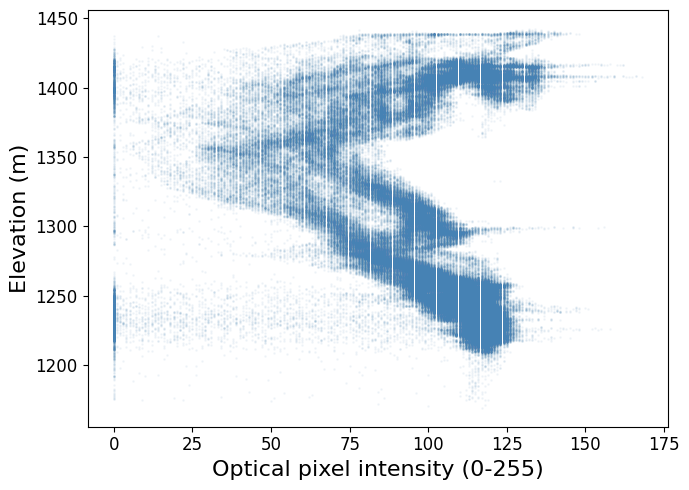

Pearson correlation (intensity vs elevation): -0.314


In [13]:
optical_gray = patch["optical"][:, :, 0]
elev         = patch["elevation"]
valid        = (patch["nan_mask"] == 0) & (patch["dev_mask"] == 0)

intensity_vals = optical_gray[valid].flatten()
elev_vals      = elev[valid].flatten()

plt.figure(figsize=(7, 5))
plt.scatter(intensity_vals, elev_vals, alpha=0.05, s=1, color="steelblue")
plt.xlabel("Optical pixel intensity (0-255)", fontsize=16)
plt.ylabel("Elevation (m)", fontsize=16)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

corr = np.corrcoef(intensity_vals, elev_vals)[0, 1]
print(f"Pearson correlation (intensity vs elevation): {corr:.3f}")

## Why a CNN? The Case Against Per-Pixel Prediction

The two visualizations above together make the core argument for why this problem requires a spatially-aware model like a U-Net CNN.

### Profile Slice
Looking at a single horizontal slice through the patch, optical intensity and elevation loosely co-vary in some regions but completely diverge in others. A pixel at intensity=100 on the left half of the image sits at a very different elevation than a pixel at intensity=100 on the right half. Brightness alone carries no consistent elevation signal.

### Scatter Plot
Across all 256k valid pixels in this patch, the Pearson correlation between optical intensity and elevation is only **-0.314** — far too weak for any per-pixel regressor to exploit. The wide vertical spread of the scatter cloud confirms that for any given brightness value, elevation could span hundreds of meters.

### The Implication
The model cannot solve this problem by learning a brightness → elevation lookup. It needs to understand **spatial context** — how brightness changes across a neighborhood, the direction and shape of shadows, the curvature of crater rims, the texture gradient across a slope. This requires a large receptive field, which is exactly what the encoder in a U-Net provides through successive pooling and convolution operations.

This is also why we use paired CTX image + DEM patches as supervision rather than any per-pixel label — the learning signal is inherently spatial, not pointwise.

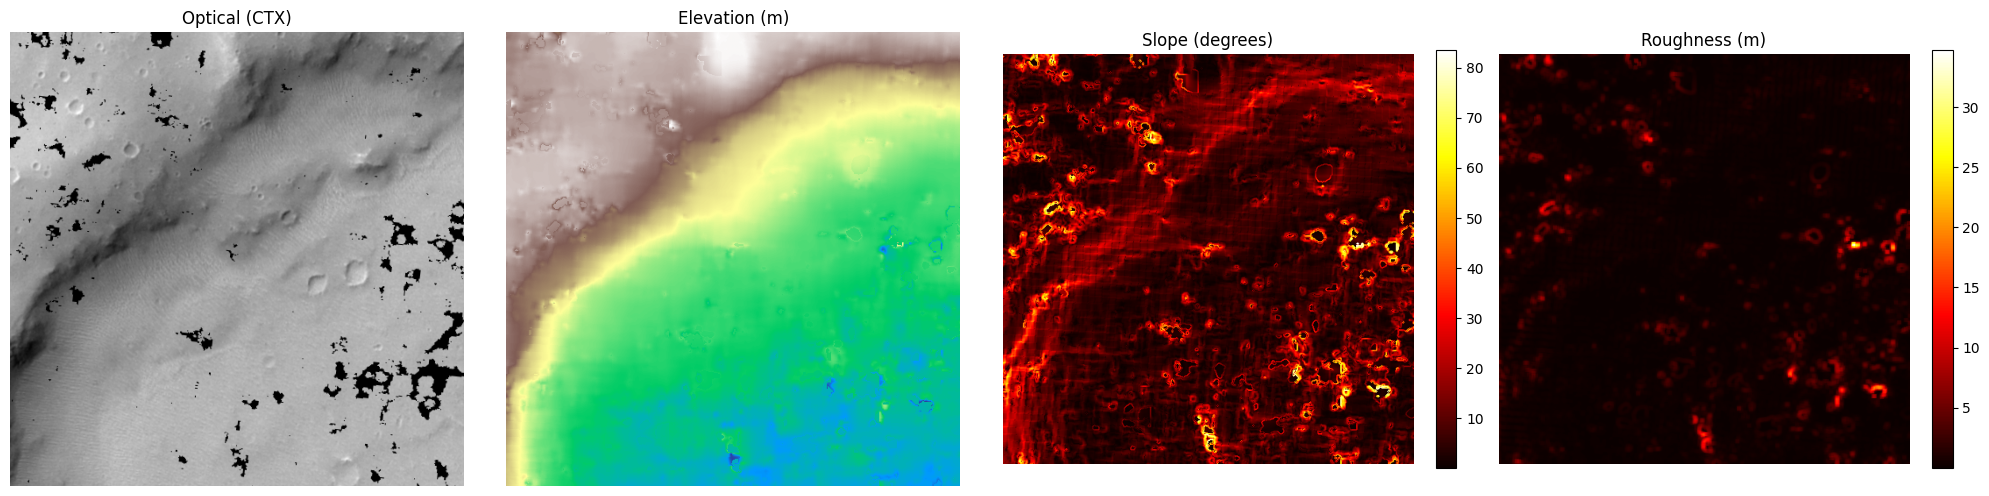

Slope     — mean: 9.23°, max: 82.84°
Roughness — mean: 0.55m, max: 33.80m


In [28]:
from scipy.ndimage import uniform_filter

def compute_slope(dem_arr, pixel_size_m=6.0):
    """Slope magnitude from finite differences, in degrees."""
    gy, gx = np.gradient(dem_arr.astype(np.float32), pixel_size_m)
    return np.degrees(np.arctan(np.sqrt(gx**2 + gy**2)))

def compute_roughness(dem_arr, window=5):
    """Roughness = std of DEM residuals after local mean subtraction."""
    local_mean = uniform_filter(dem_arr.astype(np.float32), size=window)
    residual   = dem_arr.astype(np.float32) - local_mean
    return uniform_filter(residual**2, size=window)**0.5

slope     = compute_slope(patch["elevation"])
roughness = compute_roughness(patch["elevation"])
valid     = (patch["nan_mask"] == 0) & (patch["dev_mask"] == 0)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(patch["optical"][:, :, 0], cmap="gray")
axes[0].set_title("Optical (CTX)")

axes[1].imshow(patch["elevation"], cmap="terrain")
axes[1].set_title("Elevation (m)")

im2 = axes[2].imshow(slope, cmap="hot")
axes[2].set_title("Slope (degrees)")
plt.colorbar(im2, ax=axes[2], fraction=0.046)

im3 = axes[3].imshow(roughness, cmap="hot")
axes[3].set_title("Roughness (m)")
plt.colorbar(im3, ax=axes[3], fraction=0.046)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.show()

print(f"Slope     — mean: {slope[valid].mean():.2f}°, max: {slope[valid].max():.2f}°")
print(f"Roughness — mean: {roughness[valid].mean():.2f}m, max: {roughness[valid].max():.2f}m")

## Slope and Roughness — Derived from the Elevation TIF

Slope and roughness are not stored in the dataset — they are **analytically derived from the elevation TIF** at runtime. This is what makes them "free" supervision signals for Implementation 3 (multi-output CNN) without requiring any additional annotation.

### Slope
Slope measures how steeply the terrain rises or falls at each pixel, expressed in degrees.

It is computed using **finite differences** — essentially measuring how much elevation changes between neighboring pixels in the horizontal (x) and vertical (y) directions:

```python
gy, gx = np.gradient(dem, pixel_size_m)
slope  = degrees(arctan(sqrt(gx² + gy²)))
```

`np.gradient` computes the partial derivatives of the DEM surface. Dividing by `pixel_size_m` (6.0 m for CTX) converts from elevation-change-per-pixel to elevation-change-per-meter, giving a physically meaningful slope angle in degrees.

- **Flat plains** → slope ≈ 0°
- **Crater walls, scarps** → slope can exceed 30–80°
- High slope regions in the map correspond exactly to the bright crater rims and the escarpment edge visible in the optical image.

### Roughness
Roughness measures how irregular or bumpy the terrain surface is at each pixel, expressed in meters.

It is computed as the **standard deviation of DEM residuals** after subtracting a locally smoothed surface:

```python
local_mean = uniform_filter(dem, size=5)   # local average over 5×5 window
residual   = dem - local_mean              # deviation from smooth surface
roughness  = uniform_filter(residual², size=5) ** 0.5
```

The idea: if you smooth the DEM with a local average and subtract it, what remains is the small-scale bumpiness — boulders, ripples, unresolved craters. The RMS of that residual is the roughness.

- **Smooth plains** → roughness ≈ 0–1 m
- **Boulder fields, dune fields** → roughness can reach 10–30 m
- Roughness is more spatially sparse than slope — most of the patch is dark (smooth) with bright hotspots at craters and terrain boundaries.

### Why These Matter for the Project
Both slope and roughness are **analytic functions of the elevation surface** — they are not independent labels, they are derived directly from the DEM. This physical relationship is what motivates the multi-output architecture in Implementation 3: by jointly supervising the model on elevation, slope, and roughness simultaneously, the shared encoder is forced to learn geometrically consistent terrain representations. A predicted elevation surface that also produces correct slope and roughness derivatives is a much stronger geometric prediction than one that only minimizes elevation error alone.

In [29]:
def normalize_optical(optical_arr):
    """Clip to 2nd-98th percentile then z-score standardize, per patch."""
    arr = optical_arr[:, :, 0].astype(np.float32)  # single channel
    p2, p98 = np.percentile(arr, 2), np.percentile(arr, 98)
    arr = np.clip(arr, p2, p98)
    arr = (arr - arr.mean()) / (arr.std() + 1e-8)  # +1e-8 avoids division by zero
    return arr

def normalize_dem(dem_arr):
    """Subtract per-patch mean elevation, preserve meter scale."""
    arr = dem_arr.astype(np.float32)
    patch_mean = arr.mean()
    arr = arr - patch_mean
    return arr, patch_mean   # return mean so we can reconstruct absolute elevation later

optical_raw  = patch["optical"][:, :, 0].astype(np.float32)
optical_norm = normalize_optical(patch["optical"])
dem_raw      = patch["elevation"]
dem_norm, dem_mean = normalize_dem(patch["elevation"])

print("── Optical ──────────────────────────────")
print(f"  Raw   : min={optical_raw.min():.1f}, max={optical_raw.max():.1f}, mean={optical_raw.mean():.1f}, std={optical_raw.std():.1f}")
print(f"  Norm  : min={optical_norm.min():.3f}, max={optical_norm.max():.3f}, mean={optical_norm.mean():.3f}, std={optical_norm.std():.3f}")
print()
print("── DEM ──────────────────────────────────")
print(f"  Raw   : min={dem_raw.min():.2f}m, max={dem_raw.max():.2f}m, mean={dem_raw.mean():.2f}m")
print(f"  Norm  : min={dem_norm.min():.2f}m, max={dem_norm.max():.2f}m, mean={dem_norm.mean():.2f}m")
print(f"  Stored mean (for reconstruction): {dem_mean:.2f}m")

── Optical ──────────────────────────────
  Raw   : min=0.0, max=168.0, mean=96.9, std=27.6
  Norm  : min=-3.527, max=1.100, mean=-0.000, std=1.000

── DEM ──────────────────────────────────
  Raw   : min=1169.36m, max=1442.18m, mean=1298.22m
  Norm  : min=-128.86m, max=143.96m, mean=0.00m
  Stored mean (for reconstruction): 1298.22m


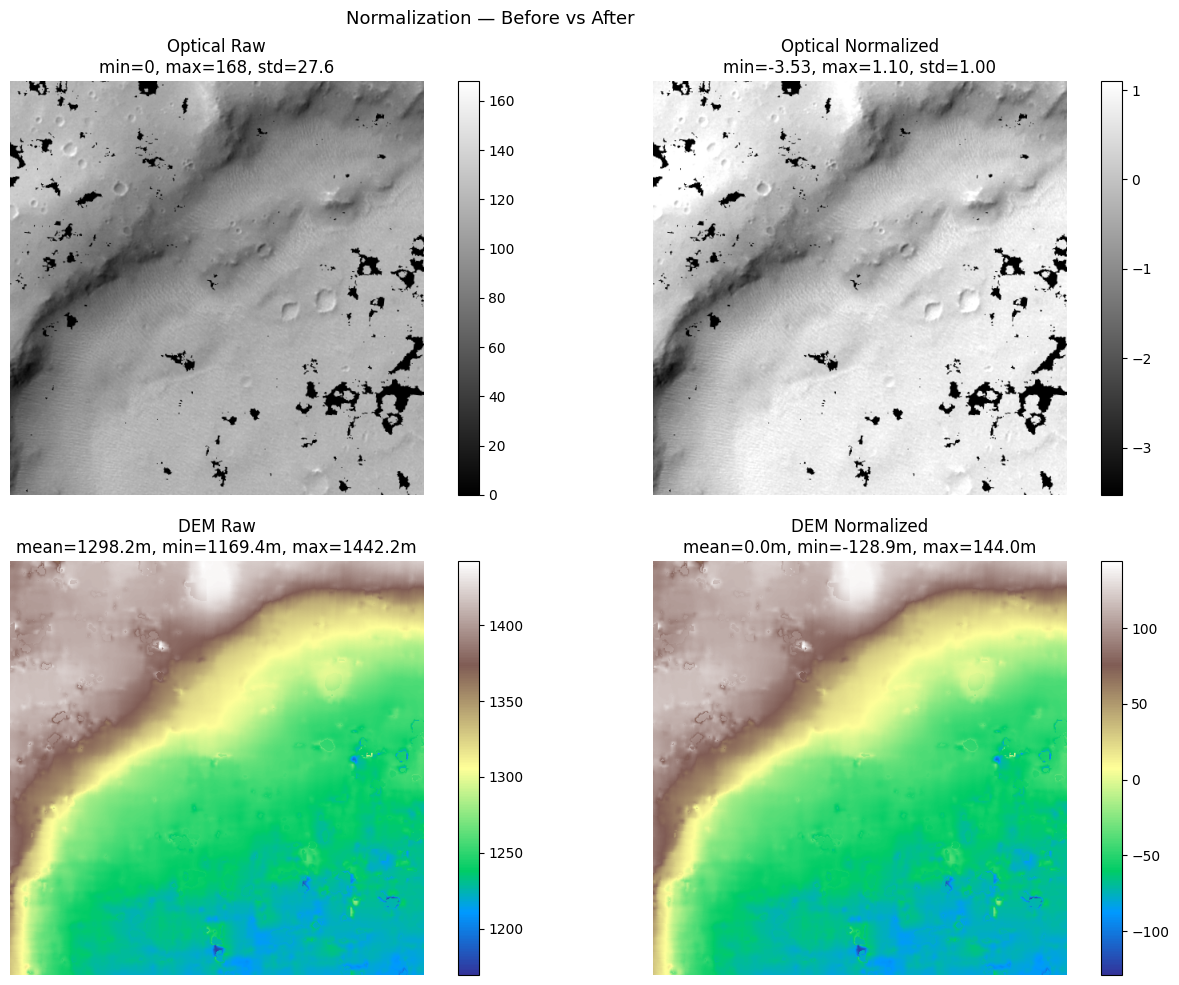

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Optical ───────────────────────────────────
im00 = axes[0][0].imshow(optical_raw, cmap="gray")
axes[0][0].set_title(f"Optical Raw\nmin={optical_raw.min():.0f}, max={optical_raw.max():.0f}, std={optical_raw.std():.1f}")
plt.colorbar(im00, ax=axes[0][0], fraction=0.046)

im01 = axes[0][1].imshow(optical_norm, cmap="gray")
axes[0][1].set_title(f"Optical Normalized\nmin={optical_norm.min():.2f}, max={optical_norm.max():.2f}, std={optical_norm.std():.2f}")
plt.colorbar(im01, ax=axes[0][1], fraction=0.046)

# ── DEM ───────────────────────────────────────
im10 = axes[1][0].imshow(dem_raw, cmap="terrain")
axes[1][0].set_title(f"DEM Raw\nmean={dem_raw.mean():.1f}m, min={dem_raw.min():.1f}m, max={dem_raw.max():.1f}m")
plt.colorbar(im10, ax=axes[1][0], fraction=0.046)

im11 = axes[1][1].imshow(dem_norm, cmap="terrain")
axes[1][1].set_title(f"DEM Normalized\nmean={dem_norm.mean():.1f}m, min={dem_norm.min():.1f}m, max={dem_norm.max():.1f}m")
plt.colorbar(im11, ax=axes[1][1], fraction=0.046)

for row in axes:
    for ax in row:
        ax.axis("off")

plt.suptitle("Normalization — Before vs After", fontsize=13)
plt.tight_layout()
plt.show()

In [31]:
from PIL import Image
import numpy as np

tif_path = list(SAMPLE_DIR.glob("*.elevation.tif"))[0]
img = Image.open(tif_path)

print(f"File          : {tif_path.name}")
print(f"Format        : {img.format}")
print(f"Mode          : {img.mode}")
print(f"Size          : {img.size}")
print(f"Info/metadata : {img.tag_v2 if hasattr(img, 'tag_v2') else 'none'}")

File          : b01_009894_1665_xi_13s042w_b02_010606_1666_xn_13s042w_00047.elevation.tif
Format        : TIFF
Mode          : F
Size          : (518, 518)
Info/metadata : {256: 518, 257: 518, 258: (32,), 259: 1, 262: 1, 273: (8, 6224, 12440, 18656, 24872, 31088, 37304, 43520, 49736, 55952, 62168, 68384, 74600, 80816, 87032, 93248, 99464, 105680, 111896, 118112, 124328, 130544, 136760, 142976, 149192, 155408, 161624, 167840, 174056, 180272, 186488, 192704, 198920, 205136, 211352, 217568, 223784, 230000, 236216, 242432, 248648, 254864, 261080, 267296, 273512, 279728, 285944, 292160, 298376, 304592, 310808, 317024, 323240, 329456, 335672, 341888, 348104, 354320, 360536, 366752, 372968, 379184, 385400, 391616, 397832, 404048, 410264, 416480, 422696, 428912, 435128, 441344, 447560, 453776, 459992, 466208, 472424, 478640, 484856, 491072, 497288, 503504, 509720, 515936, 522152, 528368, 534584, 540800, 547016, 553232, 559448, 565664, 571880, 578096, 584312, 590528, 596744, 602960, 609176, 615

## What is a TIF File and Why Do We Normalize?

### What is a TIF File?
A TIFF (Tagged Image File Format) is a flexible container format that can store much more than just a regular image. Unlike a PNG which stores uint8 values (0–255), a TIFF can store:
- **Any data type** — uint8, uint16, int32, float32, float64
- **Multiple channels** — single channel, RGB, or more
- **Geospatial metadata** — pixel scale in meters, coordinate reference system, geographic bounding box

In MCTED, the `.elevation.tif` file stores **float32 values where each pixel = elevation in meters** above the Martian areoid. There is no "color" here — the number stored at each pixel is a physical measurement in meters, produced by the CTX stereo photogrammetry pipeline. This is why we can open it with PIL and get a 518×518 float32 array directly — each pixel value is literally an elevation reading.

The `.optical.png` on the other hand is a standard uint8 image — pixel values are just brightness (0–255), with no physical unit attached.

### Why Normalize the Optical Image?
The CTX camera captures Mars under wildly different illumination conditions across the planet:
- Equatorial regions are brighter than polar regions
- Morning vs afternoon imaging changes shadow angles and overall brightness
- Different surface albedo (reflectivity) means dark basalt plains look completely different from bright dust-covered plains

Without normalization, a patch from a bright equatorial region and a patch from a dark polar region would have completely different input ranges. The model would waste capacity learning illumination differences instead of terrain geometry.

**What we do:**
1. **Percentile clipping (2nd–98th)** — removes extreme outlier pixels caused by sensor noise or deep shadows, without throwing away real terrain signal
2. **Z-score standardization** — centers the patch around 0 with std=1, making every patch comparable regardless of absolute brightness

After normalization, the model sees consistent input regardless of where on Mars the patch came from.

### Why Normalize the DEM?
Raw DEM values are absolute elevations above the Martian areoid — a patch near Olympus Mons sits at ~20,000m while a patch in Hellas Basin sits at ~-7,000m. If we trained on raw elevations, the model would need to learn the absolute altitude of every region of Mars, which is:
- **Not learnable from a single patch** — there is no visual cue in the optical image that tells you "this is at 1298m above areoid"
- **Not what we care about** — what matters for terrain characterization is the shape of the surface, not its absolute altitude

**What we do:**
- **Subtract the per-patch mean** — converts absolute elevation to relative topography. Now every patch is centered at 0m and the values represent "how much higher or lower is this pixel than the average elevation of this patch"
- **Do NOT divide by std** — we preserve the meter scale so that MAE and RMSE remain physically interpretable. An error of 10m means the model is wrong by 10 actual meters.

The stored patch mean allows us to reconstruct absolute elevation at inference time by simply adding it back:
```python
absolute_elevation = model_prediction + patch_mean
```